#Flights Delay Prediction – Two ANN Models (Binary + Regression)
Author: Laura Lugo

Date: 2026-02-06


Description:

    This Colab notebook implements two neural network models
    to predict flight delays:
    1) Binary ANN –  predict if a flight is delayed more than 15 minutes
    2) Regression ANN – predicts total delay in minutes.
    


#1) Mount Google Drive

In [1]:
# Mount Google Drive to access dataset
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


#2) Imports

In [2]:
# 2) Imports

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#3) Load dataset function

In [3]:
def load_dataset(data_dir: str, nrows: int = None) -> pd.DataFrame:
    for root, _, files in os.walk(data_dir):
        for f in files:
            if f.endswith(".csv"):
                return pd.read_csv(os.path.join(root, f), nrows=nrows)
    raise FileNotFoundError("No CSV file found.")


#4) Dataset loading

In [4]:
DATA_DIR = "/content/drive/MyDrive/DeepLearning_Project"
FIG_DIR = "/content/drive/MyDrive/DeepLearning_Project/outputs/figs"
os.makedirs(FIG_DIR, exist_ok=True)

NROWS = 300_000
DELAY_THRESHOLD = 15.0

df = load_dataset(DATA_DIR, NROWS)
print("Dataset shape:", df.shape)

Dataset shape: (300000, 23)


#5) Target construction

In [5]:
delay_cols = [
    "Carrier Delay",
    "Weather Delay",
    "Airport Delay",
    "Security Delay",
    "Late Aircraft Delay"
]

df[delay_cols] = df[delay_cols].fillna(0)
df["total_delay"] = df[delay_cols].sum(axis=1)

# Cap extreme delays
delay_cap = df["total_delay"].quantile(0.99)
df["total_delay"] = np.clip(df["total_delay"], 0, delay_cap)

df["is_delayed"] = (df["total_delay"] > DELAY_THRESHOLD).astype(int)



#6) Feature selection

In [6]:
num_features = [
    "Fly Time Scheduled",
    "Distance Miles",
    "Departure Block Hour",
    "Arrival Time Block",
    "Day Of Week",
    "Day of Month",
    "Month"
]

cat_features = [
    "Origin Airport Code",
    "Destination Airport Code"
]

df[num_features] = df[num_features].fillna(df[num_features].median())




7) Encoding & feature matrix

In [7]:
ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_cat = ohe.fit_transform(df[cat_features])
X_num = df[num_features].values

X = np.hstack([X_num, X_cat])

y_bin = df["is_delayed"].values
y_reg = df["total_delay"].values




#8) Train / Test split

In [8]:
X_train, X_test, y_train_bin, y_test_bin, y_train_reg, y_test_reg = train_test_split(
    X, y_bin, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)


#9) Feature Scaling

In [9]:
scaler = StandardScaler()

X_train[:, :len(num_features)] = scaler.fit_transform(
    X_train[:, :len(num_features)]
)
X_test[:, :len(num_features)] = scaler.transform(
    X_test[:, :len(num_features)]
)


#10) Binary classification ANN

In [10]:
input_dim = X_train.shape[1]

model_reg = Sequential([
    Dense(128, activation="relu", input_dim=input_dim),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="linear")
])

model_reg.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#11) Regression ANN

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


#12) Callbacks

In [12]:
history_reg = model_reg.fit(
    X_train,
    y_train_reg,
    validation_split=0.2,
    epochs=80,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 6595.8145 - mae: 51.2173 - val_loss: 5523.3726 - val_mae: 46.6787 - learning_rate: 0.0010
Epoch 2/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 5596.5381 - mae: 47.9237 - val_loss: 5504.5464 - val_mae: 47.5956 - learning_rate: 0.0010
Epoch 3/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 5576.1372 - mae: 47.9832 - val_loss: 5500.7085 - val_mae: 47.6596 - learning_rate: 0.0010
Epoch 4/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 5626.0811 - mae: 48.2229 - val_loss: 5506.2676 - val_mae: 48.5997 - learning_rate: 0.0010
Epoch 5/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5624.5332 - mae: 48.1836 - val_loss: 5503.3047 - val_mae: 46.7847 - learning_rate: 0.0010
Epoch 6/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 5712.9048 - mae: 48.4686 - val_loss: 5502.3018 - val_mae: 47.2601 - learning_rate: 0.0010
Epoch 7/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 5550.1279 - mae: 47.8061 

#13) Model training

In [13]:
y_train_reg_pred = model_reg.predict(X_train).ravel()
y_test_reg_pred = model_reg.predict(X_test).ravel()

X_train_aug = np.column_stack([X_train, y_train_reg_pred])
X_test_aug = np.column_stack([X_test, y_test_reg_pred])

7500/7500 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


#14) Classification evaluation

In [14]:
classes = np.unique(y_train_bin)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_bin
)

class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)


Class weights: {np.int64(0): np.float64(15.739769150052465), np.int64(1): np.float64(0.5164044479636452)}


#15) Plots

In [15]:
input_dim_aug = X_train_aug.shape[1]

model_bin = Sequential([
    Dense(128, activation="relu", input_dim=input_dim_aug),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model_bin.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC", "Precision", "Recall"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#16) Training curves

In [16]:
history_bin = model_bin.fit(
    X_train_aug,
    y_train_bin,
    validation_split=0.2,
    epochs=80,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - AUC: 0.5101 - Precision: 0.9697 - Recall: 0.5366 - loss: 0.7748 - val_AUC: 0.5353 - val_Precision: 0.9167 - val_Recall: 7.1035e-04 - val_loss: 0.7330 - learning_rate: 0.0010
Epoch 2/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.5324 - Precision: 0.9705 - Recall: 0.5359 - loss: 0.6969 - val_AUC: 0.5641 - val_Precision: 0.9710 - val_Recall: 0.7856 - val_loss: 0.6443 - learning_rate: 0.0010
Epoch 3/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - AUC: 0.5443 - Precision: 0.9722 - Recall: 0.5531 - loss: 0.6901 - val_AUC: 0.5649 - val_Precision: 0.9706 - val_Recall: 0.8054 - val_loss: 0.6421 - learning_rate: 0.0010
Epoch 4/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.5602 - Precision: 0.9733 - Recall: 0.5600 - loss: 0.6872 - val_AUC: 0.5609 - val_Precision: 0.9748 - val_Recall: 0.3048 - val_loss: 0.7345 - learning_rate: 0.0010
Epoch 5/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.5673 - Precision: 0.9728 - 

#17) Optimal threshold

In [17]:
y_test_pred_prob = model_bin.predict(X_test_aug).ravel()

roc_auc = roc_auc_score(y_test_bin, y_test_pred_prob)

precision, recall, thresholds = precision_recall_curve(
    y_test_bin, y_test_pred_prob
)

precision = precision[:-1]
recall = recall[:-1]

f1_scores = (2 * precision * recall) / (precision + recall + 1e-8)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

y_pred_class = (y_test_pred_prob >= optimal_threshold).astype(int)

f1_opt = f1_score(y_test_bin, y_pred_class)

print(f"ROC AUC: {roc_auc:.3f}")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Optimal F1-score: {f1_opt:.3f}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
ROC AUC: 0.570
Optimal threshold: 0.332
Optimal F1-score: 0.984


#18) Plots

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, average_precision_score,
    precision_recall_curve
)

plt.style.use("seaborn-v0_8")

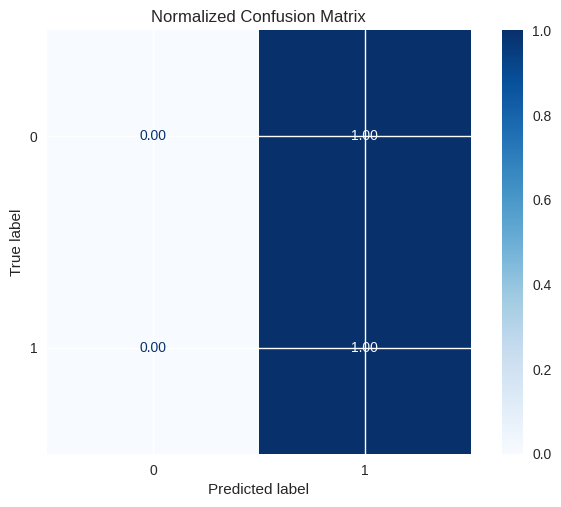

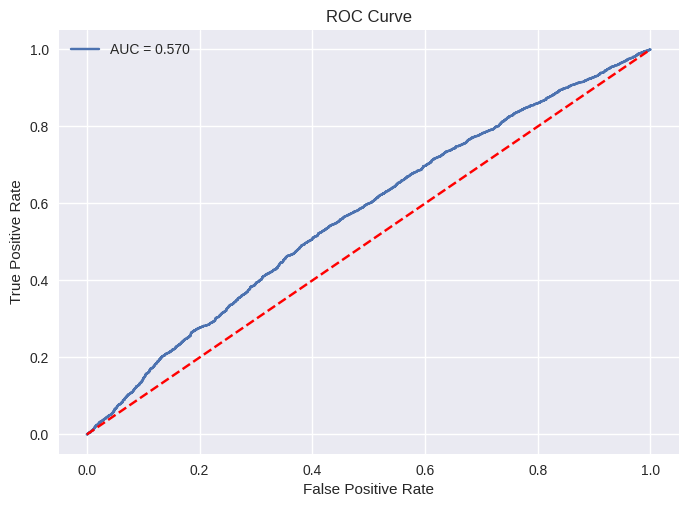

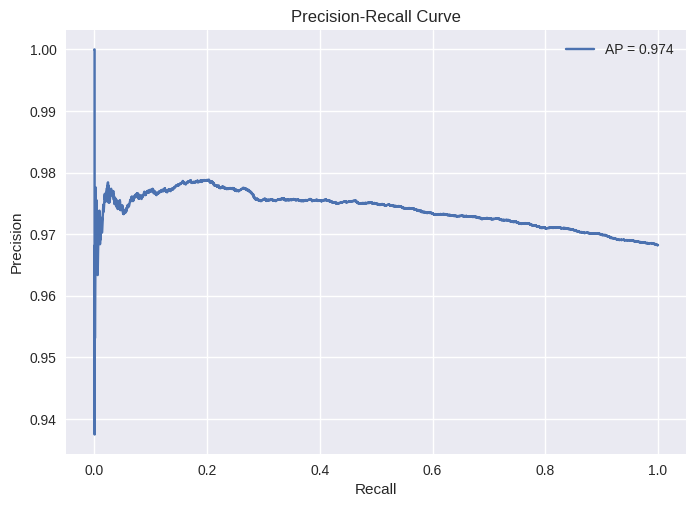

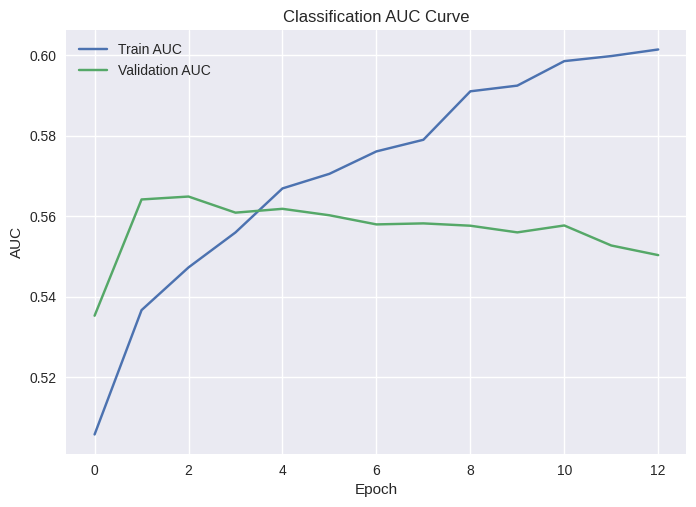

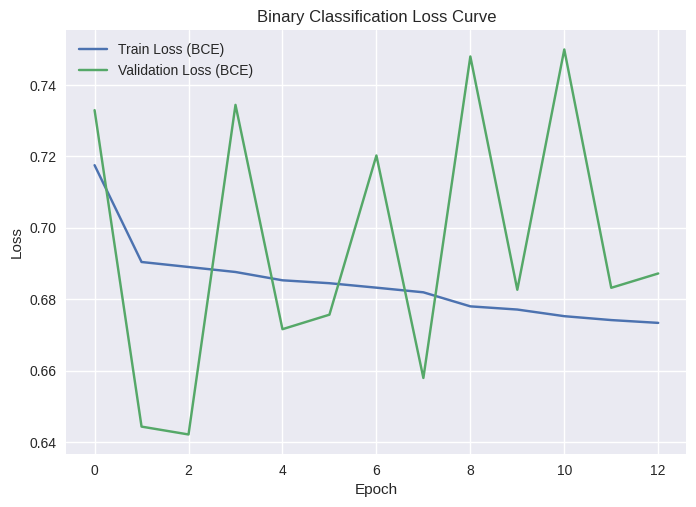

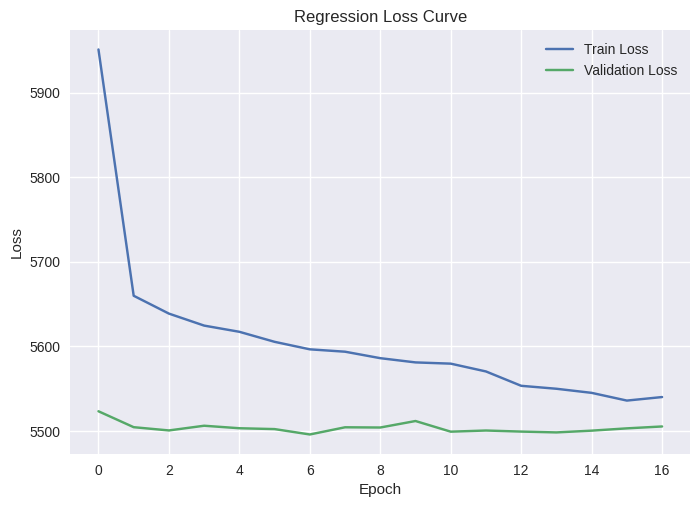

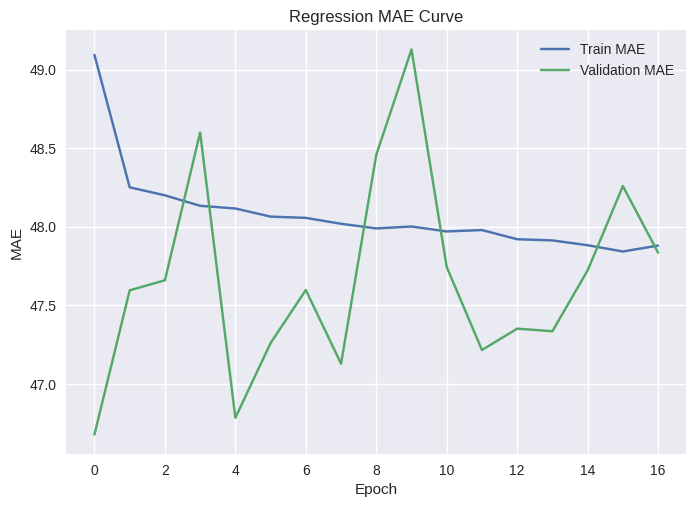

In [19]:
# 1) CONFUSION MATRIX NORMALIZED

cm = confusion_matrix(y_test_bin, y_pred_class, normalize="true")
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix")
plt.savefig(f"{FIG_DIR}/confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 2) ROC CURVE

fpr, tpr, _ = roc_curve(y_test_bin, y_test_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(f"{FIG_DIR}/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 3) PRECISION–RECALL CURVE

precision, recall, _ = precision_recall_curve(y_test_bin, y_test_pred_prob)
ap = average_precision_score(y_test_bin, y_test_pred_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig(f"{FIG_DIR}/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 4) BINARY CLASSIFIER — AUC TRAIN VS VAL

plt.figure()
plt.plot(history_bin.history["AUC"], label="Train AUC")
plt.plot(history_bin.history["val_AUC"], label="Validation AUC")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Classification AUC Curve")
plt.savefig(f"{FIG_DIR}/classification_auc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 5) BINARY CLASSIFIER — LOSS TRAIN VS VAL

plt.figure()
plt.plot(history_bin.history["loss"], label="Train Loss (BCE)")
plt.plot(history_bin.history["val_loss"], label="Validation Loss (BCE)")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Binary Classification Loss Curve")
plt.savefig(f"{FIG_DIR}/binary_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 6) REGRESSION MODEL — LOSS (Huber/MSE)

plt.figure()
plt.plot(history_reg.history["loss"], label="Train Loss")
plt.plot(history_reg.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regression Loss Curve")
plt.savefig(f"{FIG_DIR}/regression_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 7) REGRESSION MODEL — MAE

if "mae" in history_reg.history:
    plt.figure()
    plt.plot(history_reg.history["mae"], label="Train MAE")
    plt.plot(history_reg.history["val_mae"], label="Validation MAE")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("Regression MAE Curve")
    plt.savefig(f"{FIG_DIR}/regression_mae_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

